## 230352K Kumara K.B.R  
### Assesment 01 - Intensity Transformations and Neighborhood Filtering
##### 1

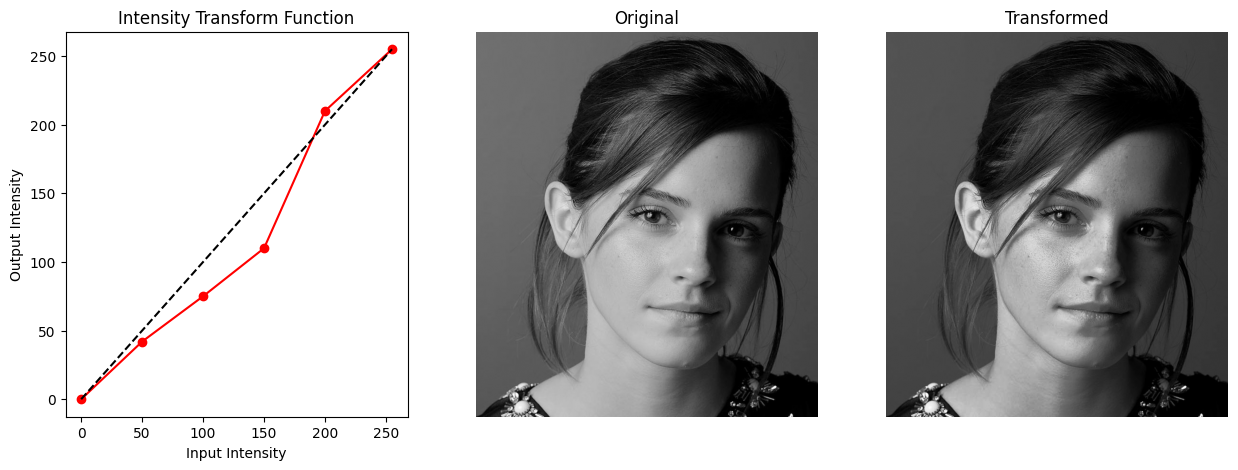

In [21]:
# importing required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def show_image_3(title, image_before, image_after=None, breakpoints=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    if breakpoints is not None:
        axes[0].plot(breakpoints[:, 0], breakpoints[:, 1], 'ro-')
        axes[0].plot(np.arange(256), np.arange(256), 'k--')
        axes[0].set_title("Intensity Transform Function")
        axes[0].set_xlabel("Input Intensity")
        axes[0].set_ylabel("Output Intensity")
    axes[1].imshow(image_before, cmap='gray')
    axes[1].set_title(title)
    axes[1].axis('off')
    if image_after is not None:
        axes[2].imshow(image_after, cmap='gray')
        axes[2].set_title("Transformed")
        axes[2].axis('off')

    plt.show()

# Intensity transform function
def intensity_transform(im, breakpoints):
    xp = breakpoints[:, 0]
    fp = breakpoints[:, 1]  
    lut = np.interp(np.arange(256), xp, fp).astype('uint8')
    return lut[im]
im1 = cv2.imread('images/q1.jpeg', cv2.IMREAD_GRAYSCALE)
breakpoints = np.array([[0, 0], [50, 42], [100, 75], [150, 110], [200, 210], [ 255, 255]])
transformed = intensity_transform(im1, breakpoints)

show_image_3("Original", im1, transformed,breakpoints)


#### 2

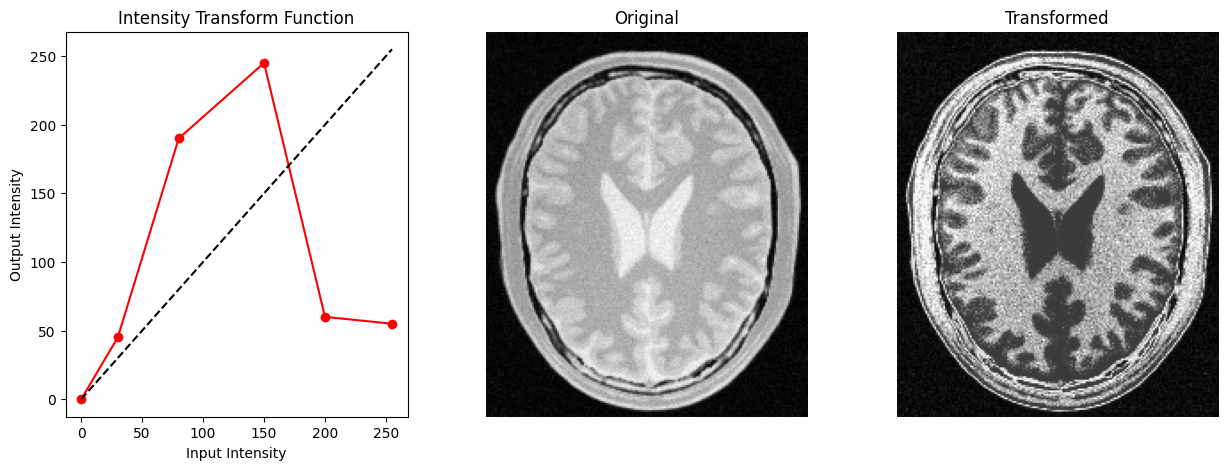

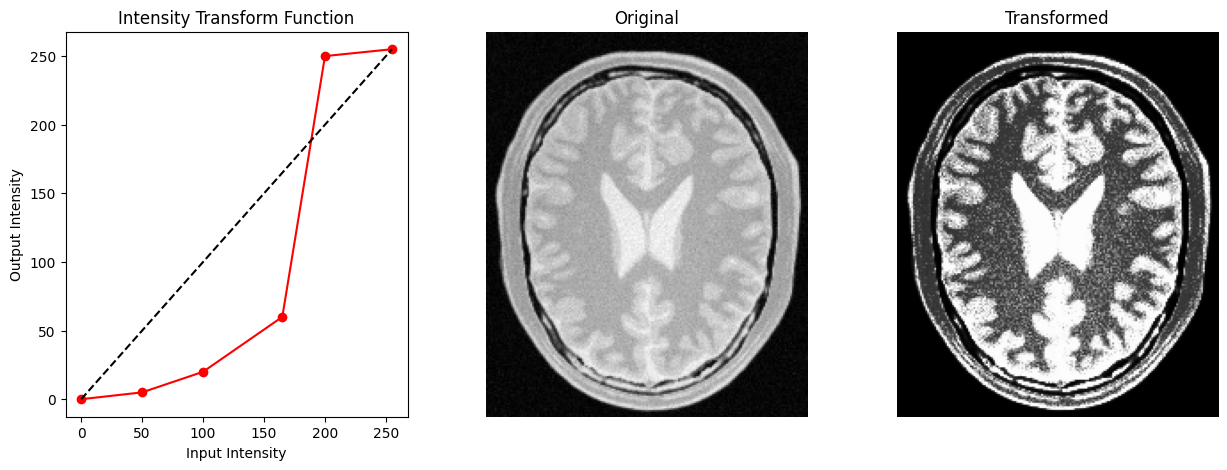

In [22]:
im2 = cv2.imread('images/q2.jpeg', cv2.IMREAD_GRAYSCALE)
white = np.array([[0, 0], [30,45], [80, 190], [150, 245],  [200, 60], [ 255, 55]])
white_accentuated = intensity_transform(im2, white)
black = np.array([[0, 0], [50, 5], [100, 20], [165, 60],  [200, 250], [ 255, 255]])
black_accentuated = intensity_transform(im2, black)
show_image_3("Original", im2, white_accentuated, white)
show_image_3("Original", im2, black_accentuated, black)

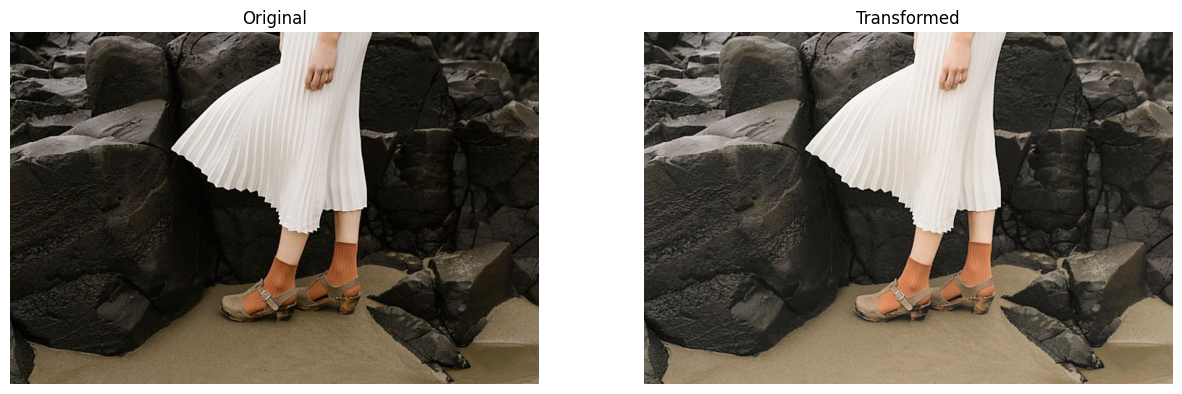

In [24]:
im3 = cv2.imread('images/q3.jpeg')
lab_image = cv2.cvtColor(im3, cv2.COLOR_BGR2LAB)
l = lab_image[:, :, 0]
gamma = 0.65
lut = np.array([((i / 255.0) ** gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
l_transformed = cv2.LUT(l, lut) 

def show_image_2(title, image_before, image_after=None):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].imshow(image_before, cmap='gray')
    axes[0].set_title(title)
    axes[0].axis('off')
    if image_after is not None:
        axes[1].imshow(image_after, cmap='gray')
        axes[1].set_title("Transformed")
        axes[1].axis('off')

    plt.show()

img_rgb_original = cv2.cvtColor(im3, cv2.COLOR_BGR2RGB)
img_rgb_corrected = cv2.cvtColor(cv2.merge((l_transformed, lab_image[:, :, 1], lab_image[:, :, 2])), cv2.COLOR_LAB2RGB)
show_image_2("Original", img_rgb_original, img_rgb_corrected)
   
